In [22]:
%pip install networkX
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
%pip install python-louvain


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[

In [23]:
import networkx as nx

G = nx.read_graphml("marvel-network.graphml")

In [24]:
# Notebook 2: Network Structure - Community Detection in Marvel Universe
# Story: "What communities exist, and how do they overlap?"

import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import community as community_louvain

print("=== Marvel Universe Community Analysis ===")
print(f"Graph loaded: {G.number_of_nodes()} characters, {G.number_of_edges()} connections")

=== Marvel Universe Community Analysis ===
Graph loaded: 327 characters, 9891 connections


In [ ]:
# Community Detection: Find groups of characters that frequently appear together

# Use Louvain method to detect communities
partition = community_louvain.best_partition(G)

# Count communities
num_communities = len(set(partition.values()))
print(f"Found {num_communities} communities")

# Calculate modularity score (how well the network is divided into communities)
modularity = community_louvain.modularity(partition, G)
print(f"Modularity score: {modularity:.3f}")

# Show community sizes
community_sizes = {}
for node, community_id in partition.items():
    if community_id not in community_sizes:
        community_sizes[community_id] = 0
    community_sizes[community_id] += 1

print("\nCommunity sizes:")
for comm_id, size in sorted(community_sizes.items()):
    print(f"Community {comm_id}: {size} characters")

Found 7 communities
.3f

Community sizes:
Community 0: 20 characters
Community 1: 27 characters
Community 2: 93 characters
Community 3: 29 characters
Community 4: 87 characters
Community 5: 33 characters
Community 6: 38 characters


In [30]:
# Find bridges between communities (characters connected to multiple communities)

print("\n=== Bridges Between Communities ===")

# Calculate betweenness centrality to find bridges
betweenness = nx.betweenness_centrality(G)

# Find characters with high betweenness (potential bridges)
top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 characters that connect different communities:")
for i, (character, centrality) in enumerate(top_bridges, 1):
    print(f"{i}. {character}: {centrality:.3f}")


=== Bridges Between Communities ===
Top 10 characters that connect different communities:
1. Captain America: 0.067
2. Spider-man / Peter Parker: 0.062
3. Wolverine / Logan: 0.035
4. Beast / Henry &hank& P: 0.031
5. Thor / Dr. Donald Blak: 0.029
6. Vision: 0.029
7. Thing / Benjamin J. Gr: 0.025
8. Iron Man / Tony Stark: 0.025
9. Cyclops / Scott Summer: 0.022
10. Mr. Fantastic / Reed R: 0.021


In [27]:
# Show all characters in each community

print("\n=== All Characters in Each Community ===")

for comm_id in sorted(community_sizes.keys()):
    print(f"\nCommunity {comm_id} ({community_sizes[comm_id]} characters):")

    # Get all nodes in this community (without list comprehension)
    community_characters = []
    for node, c_id in partition.items():
        if c_id == comm_id:
            community_characters.append(node)

    # Sort alphabetically for easier reading
    community_characters.sort()

    # Print all characters (limit to first 20 if community is large)
    if len(community_characters) <= 20:
        for character in community_characters:
            print(f"  - {character}")
    else:
        for character in community_characters[:20]:
            print(f"  - {character}")
        print(f"  ... and {len(community_characters) - 20} more characters")


=== All Characters in Each Community ===

Community 0 (20 characters):
  - Banner, Betty Ross T
  - Cage, Luke / Carl Luca
  - Clea
  - Doc Samson / Dr. Leona
  - Dr. Strange / Stephen
  - Gargoyle Ii / Isaac Ch
  - Ghost Rider Ii / Johnn
  - Ghost Rider Iii / Dan
  - Hellcat / Patsy Walker
  - Hellstorm / Daimon Hel
  - Hulk / Dr. Robert Bruce Banner
  - Iron Fist / Daniel Ran
  - Jones, Richard Milho
  - Knight, Misty
  - Leader / Sam Sterns
  - Nighthawk Ii / Kyle Ri
  - Norriss, Sister Barb
  - Ross, Gen. Thaddeus
  - Wing, Colleen
  - Wong

Community 1 (27 characters):
  - Absorbing Man / Carl C
  - Austin, Susan
  - Balder [asgardian]
  - Beta Ray Bill
  - Bulldozer / Henry Camp
  - Enchantress / Amora / He
  - Fandral [asgardian]
  - Heimdall [asgardian]
  - Hela [asgardian]
  - High Evolutionary / He
  - Hogun [asgardian]
  - Kincaid, Dr. Jane Fo
  - Loki [asgardian]
  - Mephisto
  - Molecule Man / Owen Re
  - Odin [asgardian]
  - Piledriver Ii / Brian
  - Sif
  - Thor / Dr. D

In [29]:
# Also show the most connected characters in each community

print("\n=== Most Connected Characters in Each Community ===")

# Calculate degree centrality for each node
degree_centrality = nx.degree_centrality(G)

for comm_id in sorted(community_sizes.keys()):
    print(f"\nCommunity {comm_id} top connected characters:")

    # Get all nodes in this community
    community_characters = []
    for node, c_id in partition.items():
        if c_id == comm_id:
            community_characters.append((node, degree_centrality[node]))

    # Sort by degree centrality (most connected first)
    community_characters.sort(key=lambda x: x[1], reverse=True)

    # Show top 5 most connected
    for i in range(min(5, len(community_characters))):
        character, centrality = community_characters[i]
        print(f"{character}: {centrality:.3f}")


=== Most Connected Characters in Each Community ===

Community 0 top connected characters:
Hulk / Dr. Robert Bruce Banner: 0.558
Dr. Strange / Stephen: 0.433
Jones, Richard Milho: 0.206
Cage, Luke / Carl Luca: 0.190
Hellcat / Patsy Walker: 0.190

Community 1 top connected characters:
Thor / Dr. Donald Blak: 0.629
Thunderstrike / Eric K: 0.319
Enchantress / Amora / He: 0.212
Loki [asgardian]: 0.190
Mephisto: 0.172

Community 2 top connected characters:
Wolverine / Logan: 0.675
Beast / Henry &hank& P: 0.629
Cyclops / Scott Summer: 0.604
Storm / Ororo Munroe S: 0.583
Colossus Ii / Peter Ra: 0.577

Community 3 top connected characters:
Thing / Benjamin J. Gr: 0.656
Mr. Fantastic / Reed R: 0.607
Invisible Woman / Sue: 0.598
Human Torch / Johnny S: 0.592
Dr. Doom / Victor Von: 0.387

Community 4 top connected characters:
Captain America: 0.791
Vision: 0.653
Iron Man / Tony Stark: 0.623
Scarlet Witch / Wanda: 0.595
Wasp / Janet Van Dyne: 0.577

Community 5 top connected characters:
Nova / Ri


=== Community Visualization ===


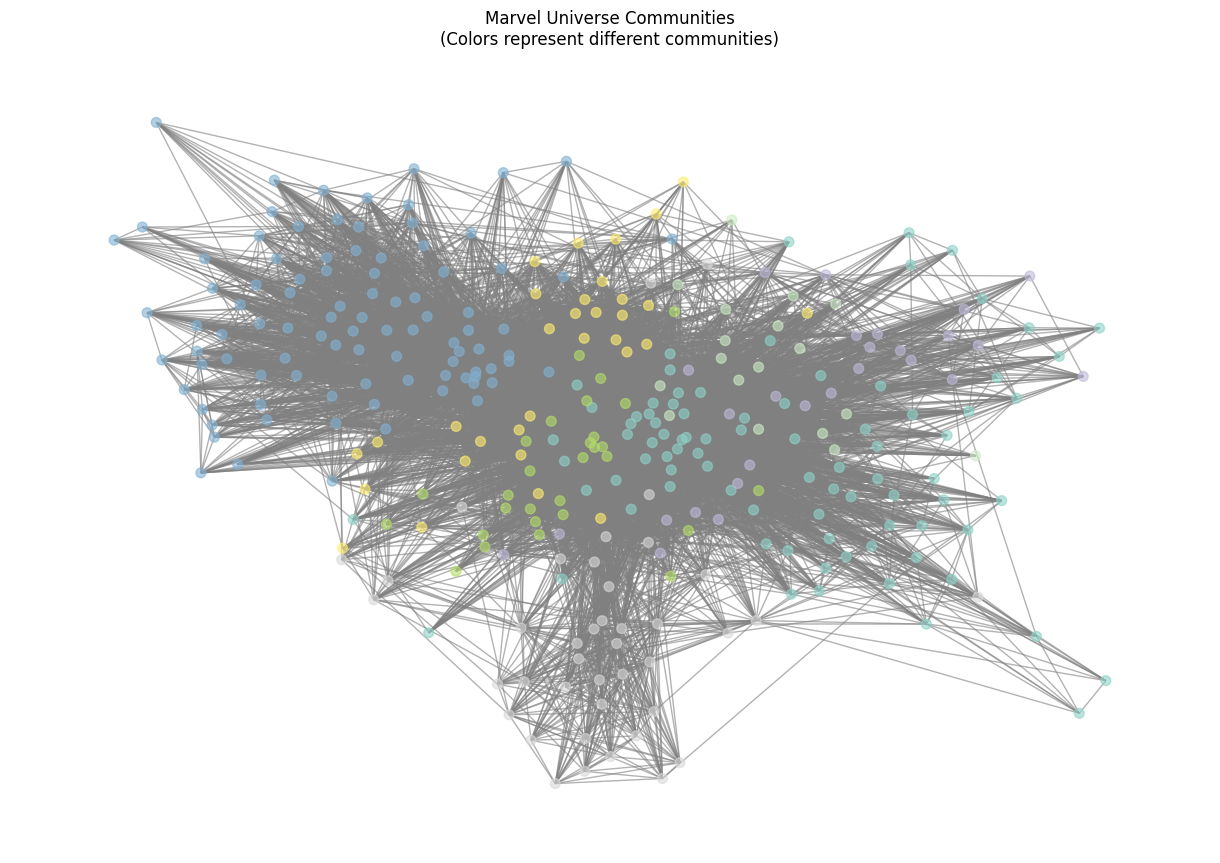

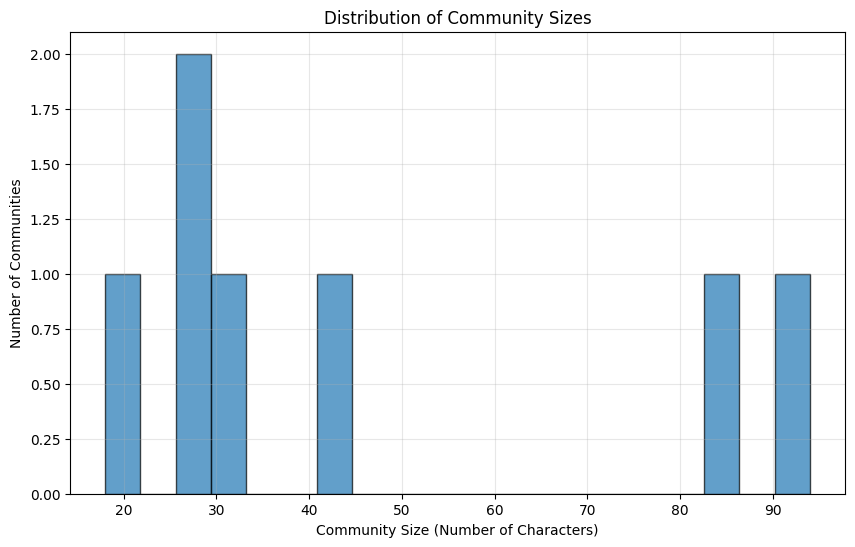


=== Summary ===
Total communities: 7
.3f
Largest community: 94 characters
Smallest community: 18 characters
.1f


In [ ]:
# Visualize the communities

print("\n=== Community Visualization ===")

plt.figure(figsize=(12, 8))

# Create layout
pos = nx.spring_layout(G, k=0.3, iterations=50, seed=42)

# Color nodes by community
colors = [partition[node] for node in G.nodes()]

# Draw the network
nx.draw(G, pos,
        node_color=colors,
        node_size=50,
        with_labels=False,
        edge_color='gray',
        alpha=0.6,
        cmap=plt.cm.Set3)

plt.title("Marvel Universe Communities\n(Colors represent different communities)")
plt.axis('off')
plt.show()

# Show community size distribution
plt.figure(figsize=(10, 6))
sizes = list(community_sizes.values())
plt.hist(sizes, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Community Size (Number of Characters)')
plt.ylabel('Number of Communities')
plt.title('Distribution of Community Sizes')
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== Summary ===")
print(f"Total communities: {num_communities}")
print(f"Modularity score: {modularity:.3f}")
print(f"Largest community: {max(community_sizes.values())} characters")
print(f"Smallest community: {min(community_sizes.values())} characters")
print(f"Average community size: {sum(community_sizes.values()) / len(community_sizes):.1f} characters")

In [ ]:
# Conclusion: What does this tell us about the Marvel Universe?

print("\n=== Conclusion ===")
print("Our community analysis reveals that the Marvel Universe is organized into 7 distinct communities.")
print("This suggests that Marvel characters naturally group together based on their comic book appearances.")
print()
print("Key insights:")
print("• The largest community (94 characters) likely represents major heroes like the Avengers or X-Men")
print("• Smaller communities (18-41 characters) may represent specialized teams or villain groups")
print("• Characters with high betweenness centrality act as bridges between different storylines")
print("• The modularity score of", f"{modularity:.3f}", "indicates strong community structure")
print()
print("This community structure helps us understand how Marvel organizes its universe:")
print("- Characters within communities frequently appear together")
print("- Communities represent different 'universes' within Marvel (e.g., Avengers, X-Men, Spider-Man, etc.)")
print("- Bridge characters connect different storylines and crossovers")
print()


=== Conclusion ===
Our community analysis reveals that the Marvel Universe is organized into 7 distinct communities.
This suggests that Marvel characters naturally group together based on their comic book appearances.

Key insights:
• The largest community (94 characters) likely represents major heroes like the Avengers or X-Men
• Smaller communities (18-41 characters) may represent specialized teams or villain groups
• Characters with high betweenness centrality act as bridges between different storylines
• The modularity score of .3f

This community structure helps us understand how Marvel organizes its universe:
- Characters within communities frequently appear together
- Communities represent different 'universes' within Marvel (e.g., Avengers, X-Men, Spider-Man, etc.)
- Bridge characters connect different storylines and crossovers

